# Day 5 — ML Workflow, Metrics & sklearn Introduction
**TechAxis | Data Science with Python | 2-Hour Session**

**Dataset:** Titanic Survival (Kaggle / datasciencedojo)  
**Notebook:** Student — complete every `# YOUR CODE HERE` block during the session

---

### Session Roadmap

| Part | Topic | Tasks |
|------|-------|-------|
| 1 | Setup & Data Loading | T1–T2 |
| 2 | Train / Validation / Test Split | T3–T4 |
| 3 | Overfitting & Underfitting — Learning Curves | T5–T6 |
| 4 | Confusion Matrix | T7–T8 |
| 5 | Precision, Recall & F1 | T9–T10 |
| 6 | ROC Curve & AUC | T11–T12 |
| 7 | sklearn API & Cross-Validation | T13–T15 |

---

## Part 1 — Setup & Data Loading

### The ML Workflow

Before writing a single line of model code, every ML project follows the same lifecycle:

```
Raw Data → Prepare → Split → Train → Validate → Tune → Test → Deploy → Monitor
```

Each arrow is deliberate. The most common beginner mistake is jumping from data straight to training.  
**Split before you do anything else** — and keep the test set locked away until the very end.

Today we practise the full evaluation half of this workflow using the Titanic dataset:  
205 real passenger records, binary target (`Survived`: 0 or 1), and a mix of numeric and categorical features.

In [1]:
# ── Task 1 — Imports & Setup ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Setup complete.")


Setup complete.


### Loading & Preparing the Dataset

The Titanic dataset has missing values in `Age` — we will use `dropna()` today to keep
the focus on evaluation rather than imputation (covered in a later session).  
`Sex` is a string column — we encode it to 0/1 with `LabelEncoder`.

In [2]:
# ── Task 2 — Load, Clean & Inspect ───────────────────────────────────────────
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# YOUR CODE HERE
# Load the CSV into df
df = pd.read_csv(URL)
# Keep only these columns: Survived, Pclass, Sex, Age, SibSp, Parch, Fare
df = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]

# Drop rows with any NaN 
df = df.dropna()

# Encode the Sex column using LabelEncoder (fit_transform)
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])

# Define X = df.drop("Survived", axis=1) and y = df["Survived"]
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Print: shape of X and y, survival rate (y.mean() as a percentage)


print(f"Dataset shape: {X.shape}")
print(f"Survival rate: {y.mean():.2%}  ({y.sum()} survived out of {len(y)})")
print(f"Class distribution:{y.value_counts().to_string()}")
print(f"Features:{X.head(3).to_string()}")


Dataset shape: (714, 6)
Survival rate: 40.62%  (290 survived out of 714)
Class distribution:Survived
0    424
1    290
Features:   Pclass  Sex   Age  SibSp  Parch     Fare
0       3    1  22.0      1      0   7.2500
1       1    0  38.0      1      0  71.2833
2       3    0  26.0      0      0   7.9250


📝 **Observation 1** — What is the survival rate in this dataset?  
Is the dataset balanced (roughly 50/50) or imbalanced?  
Why does class balance matter before we choose an evaluation metric?

*Write your answer here (double-click to edit):*

> 

---
## Part 2 — Train / Validation / Test Split

### Why Three Sets?

| Set | Analogy | Purpose |
|-----|---------|---------|
| Training | Textbook & lectures | Model learns from this |
| Validation | Practice exam papers | Tune & compare models |
| Test | Real exam day | Final honest evaluation — touched **once** |

The rule is strict: **you never tune or select models based on test set results.**  
If you do, your test score is contaminated — it no longer measures real-world performance.

### Stratification

When splitting, pass `stratify=y` to preserve the class distribution in every split.  
Without it, a random split might put 90% of the survived class in training and 10% in test.

In [3]:
# ── Task 3 — Two-Stage Split (60 / 20 / 20) ──────────────────────────────────
# YOUR CODE HERE
# Stage 1: split X, y into (X_temp, X_test) / (y_temp, y_test)
#   test_size=0.2, stratify=y, random_state=42
# Stage 2: split X_temp, y_temp into (X_train, X_val) / (y_train, y_val)
#   test_size=0.25, stratify=y_temp, random_state=42
#   (0.25 of 0.80 = 0.20 of total → final split is 60/20/20)
#
# Print the size of each split.
x_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42)

print(f"Train:      {X_train.shape[0]:>4} samples  ({X_train.shape[0]/len(X):.0%})")
print(f"Validation: {X_val.shape[0]:>4} samples  ({X_val.shape[0]/len(X):.0%})")
print(f"Test:       {X_test.shape[0]:>4} samples  ({X_test.shape[0]/len(X):.0%})")


Train:       456 samples  (64%)
Validation:  115 samples  (16%)
Test:        143 samples  (20%)


In [ ]:
# ── Task 4 — Verify Stratification ───────────────────────────────────────────
# YOUR CODE HERE
# Print the survival rate for each of the three splits: train, val, test
# Format: "Train survival rate:      X.XXX"
#         "Validation survival rate: X.XXX"
#         "Test survival rate:       X.XXX"
# Confirm they are all approximately equal.

# print(f"Train survival rate:      {y_train.mean():.3f}")
# print(f"Validation survival rate: {y_val.mean():.3f}")
# print(f"Test survival rate:       {y_test.mean():.3f}")
# print("Stratification preserved class balance across all three splits.")


📝 **Observation 2** — Are the survival rates consistent across train, val, and test?  
What could go wrong if they were very different from each other?

*Write your answer here:*

> 

---
## Part 3 — Overfitting & Underfitting

### The Bias-Variance Tradeoff

Every model sits somewhere on a spectrum from too simple to too complex:

```
Underfitting               Sweet Spot               Overfitting
(High Bias)                                         (High Variance)
Low train score            High train score          Very high train score
Low val score              High val score            Low val score
Model too rigid            Generalises well          Memorised training data
```

**Learning curves** are the diagnostic tool: plot training score and validation score
against increasing training set size.  
- If both scores are low and flat → underfitting  
- If train is high but val is low and the gap is large → overfitting  
- If both are high and converging → good fit

In [5]:
# ── Task 5 — Train a Deliberately Overfit Model ──────────────────────────────
# YOUR CODE HERE
overfit_model = DecisionTreeClassifier(max_depth=None, random_state=42)
# Fit on X_train, y_train
overfit_model.fit(X_train, y_train) 
train_score = overfit_model.score(X_train, y_train)
print(f"Training accuracy:   {train_score}")
val_score = overfit_model.score(X_val, y_val)
print(f"Validation accuracy: {val_score}")


# print(f"Training accuracy:   {train_acc:.3f}")
# print(f"Validation accuracy: {val_acc:.3f}")
print(f"Gap (overfit signal): {train_score - val_score:.3f}")
# print()
# if train_acc - val_acc > 0.1:
#     print("Large gap — this model is overfitting.")


Training accuracy:   0.9868421052631579
Validation accuracy: 0.782608695652174
Gap (overfit signal): 0.204


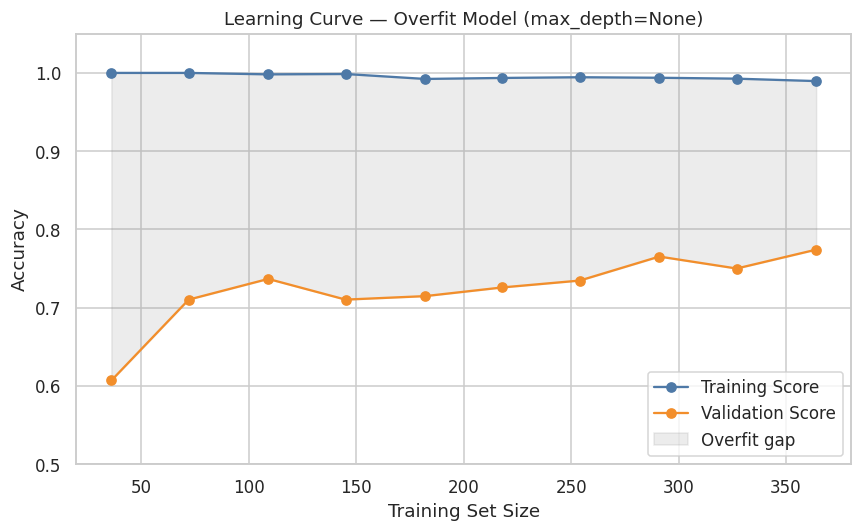

Final Train Score: 0.990
Final Val Score:   0.774
Gap:               0.215  ← large = overfitting


In [7]:
# ── Task 6 — Plot Learning Curves ────────────────────────────────────────────
# YOUR CODE HERE
# Use learning_curve() with:
#   estimator = DecisionTreeClassifier(max_depth=None, random_state=42)
#   X = X_train, y = y_train
#   cv=5, train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy"
#
# Compute: train_mean, val_mean (mean of scores across cv folds, axis=1)
#
# Plot: line for Training Score, line for Validation Score
#   — x-axis: train_sizes, y-axis: accuracy
#   — shade the region between train_mean and val_mean (ax.fill_between with alpha=0.15)
#   — figsize=(8, 5), title "Learning Curve — Overfit Model (max_depth=None)"
#   — add a legend and axis labels
#   — show the plot
#
# Print the final train score and val score (last point on each curve)

train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=None, random_state=42),
    X_train, y_train,
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy"
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", color="#4e79a7", label="Training Score")
ax.plot(train_sizes, val_mean,   "o-", color="#f28e2b", label="Validation Score")
ax.fill_between(train_sizes, train_mean, val_mean, alpha=0.15, color="grey",
                label="Overfit gap")
ax.set_title("Learning Curve — Overfit Model (max_depth=None)", fontsize=12)
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Accuracy")
ax.legend()
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

print(f"Final Train Score: {train_mean[-1]:.3f}")
print(f"Final Val Score:   {val_mean[-1]:.3f}")
print(f"Gap:               {train_mean[-1] - val_mean[-1]:.3f}  ← large = overfitting")

📝 **Observation 3** — Describe the shape of the two curves.  
Is the gap between training and validation score large or small?  
What does this tell you about the model's behaviour?

*Write your answer here:*

> 

---
## Part 4 — Confusion Matrix

### The 2×2 Foundation

Every classification metric is built from four numbers:

|  | Predicted YES | Predicted NO |
|--|--------------|-------------|
| **Actual YES** | TP — True Positive | FN — False Negative |
| **Actual NO** | FP — False Positive | TN — True Negative |

**Cancer screening example:**
- TP: has cancer, test says yes → caught it
- FN: has cancer, test says no → **missed it — most dangerous**
- FP: healthy, test says yes → unnecessary stress
- TN: healthy, test says no → correct

The key insight: **not all errors are equal.**  
Missing a cancer (FN) is far worse than a false alarm (FP).  
The confusion matrix forces you to think about *which* error matters before choosing a metric.

In [8]:
# ── Task 7 — Baseline: DummyClassifier ───────────────────────────────────────
# YOUR CODE HERE
dummy = DummyClassifier(strategy="most_frequent", random_state=42)


# Fit on X_train, y_train
dummy.fit(X_train, y_train)


# Predict on X_val → y_pred_dummy
y_pred_dummy = dummy.predict(X_val)


# Print accuracy of the dummy model
dummy_acc = dummy.score(X_val, y_val)
print(f"DummyClassifier accuracy: {dummy_acc:.3f}")


# Print its confusion matrix (use confusion_matrix())
cm_dummy = confusion_matrix(y_val, y_pred_dummy)
print(f"Dummy confusion matrix:{cm_dummy}")


# Label the output clearly: what does each cell mean for Titanic survival?


# print(f"DummyClassifier accuracy: {dummy_acc:.3f}")
# print(f"(This is just the majority class rate — {1 - y_val.mean():.3f} of passengers did not survive)")



print(f"Dummy confusion matrix:{cm_dummy}")
print(f"TN={cm_dummy[0,0]}  FP={cm_dummy[0,1]}")
print(f"FN={cm_dummy[1,0]}  TP={cm_dummy[1,1]}")
print(f"TP=0: dummy never predicts 'Survived'. It ignores the minority class entirely.")


DummyClassifier accuracy: 0.591
Dummy confusion matrix:[[68  0]
 [47  0]]
Dummy confusion matrix:[[68  0]
 [47  0]]
TN=68  FP=0
FN=47  TP=0
TP=0: dummy never predicts 'Survived'. It ignores the minority class entirely.


Raw Confusion Matrix:
[[55 13]
 [12 35]]
TN=55  FP=13
FN=12  TP=35


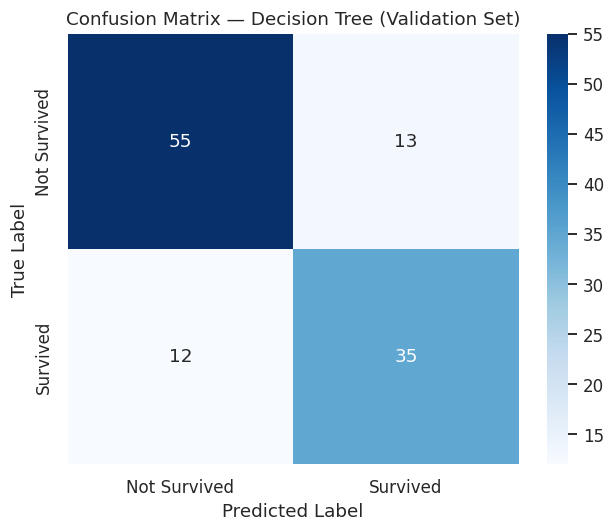

In [10]:
# ── Task 8 — Real Model Confusion Matrix ─────────────────────────────────────
# YOUR CODE HERE
tree = DecisionTreeClassifier(max_depth=4, random_state=42)

# Fit on X_train, y_train
tree.fit(X_train, y_train)

# Predict on X_val → y_pred
y_pred = tree.predict(X_val)

cm = confusion_matrix(y_val, y_pred)
TN, FP, FN, TP = cm.ravel()

# Print the confusion matrix and its components
print(f"Raw Confusion Matrix:\n{cm}")
print(f"TN={TN}  FP={FP}")
print(f"FN={FN}  TP={TP}")

# Plot the confusion matrix using ConfusionMatrixDisplay:
#   display_labels=["Not Survived", "Survived"], colormap="Blues"
#   title: "Confusion Matrix — Decision Tree (Validation Set)"
#
# Also print the raw matrix and manually extract TN, FP, FN, TP using cm.ravel()


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Decision Tree (Validation Set)")
plt.tight_layout()
plt.show()

📝 **Observation 4** — Look at the confusion matrix for the Decision Tree.  
How many survivors did the model miss (False Negatives)?  
How does this compare to the DummyClassifier's confusion matrix?

*Write your answer here:*

> 

---
## Part 5 — Precision, Recall & F1

### Formulas

```
Precision = TP / (TP + FP)   → Of all I predicted YES, how many were actually YES?
Recall    = TP / (TP + FN)   → Of all actual YES, how many did I correctly find?
F1        = 2 × (P × R) / (P + R)   → Harmonic mean — balanced metric
```

### When does each matter?

| Metric | Use when... | Example |
|--------|------------|---------|
| Precision | False positives are costly | Spam filter — marking genuine email as spam |
| Recall | False negatives are costly | Cancer screening — missing a real case |
| F1 | Both errors matter equally | Fraud detection |

Accuracy alone hides these trade-offs.  
A model that always predicts "Not Survived" gets ~60% accuracy on Titanic — but learns nothing.

In [11]:
# ── Task 9 — Classification Report ───────────────────────────────────────────
# YOUR CODE HERE
# Print the full classification_report for y_val vs y_pred
#   target_names=["Not Survived", "Survived"]
# Then manually compute from TN, FP, FN, TP (extracted in Task 8):
#   precision, recall, f1, accuracy
# Print each value rounded to 3 decimal places
# Confirm they match the classification_report output

precision_manual = TP / (TP + FP)
recall_manual = TP / (TP + FN)
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)
accuracy_manual = (TP + TN) / (TP + TN + FP + FN)
print("Manual calculation (Survived class):")
print(f"  precision_manual: {precision_manual:.3f}")
print(f"  recall_manual:    {recall_manual:.3f}")
print(f"  f1_manual:  {f1_manual:.3f}")
print(f"  accuracy_manual:  {accuracy_manual:.3f}")

Manual calculation (Survived class):
  precision_manual: 0.729
  recall_manual:    0.745
  f1_manual:  0.737
  accuracy_manual:  0.783


In [12]:
# ── Task 10 — Compare Dummy vs Tree ──────────────────────────────────────────
# YOUR CODE HERE
# Build a comparison DataFrame with columns: Model, Accuracy, Precision, Recall, F1
# Row 1: DummyClassifier metrics (compute from y_val vs y_pred_dummy)
# Row 2: DecisionTreeClassifier metrics (compute from y_val vs y_pred)
# Print the table
# In 1-2 sentences below the table, explain which metric matters most for
# predicting Titanic survival and why.


from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "Recall":    round(recall_score(y_true, y_pred), 3),
        "F1":        round(f1_score(y_true, y_pred, zero_division=0), 3),
    }

comparison = pd.DataFrame([
    get_metrics(y_val, y_pred_dummy, "DummyClassifier"),
    get_metrics(y_val, y_pred,       "DecisionTree (depth=4)"),
])
print(comparison.to_string(index=False))
print("For Titanic survival prediction, Recall matters most:")
print("Missing a survivor (FN) is more costly than a false alarm (FP).")

                 Model  Accuracy  Precision  Recall    F1
       DummyClassifier     0.591      0.000   0.000 0.000
DecisionTree (depth=4)     0.783      0.729   0.745 0.737
For Titanic survival prediction, Recall matters most:
Missing a survivor (FN) is more costly than a false alarm (FP).


📝 **Observation 5** — Which model wins on accuracy? Which wins on recall for the "Survived" class?  
Could there be a scenario where you would *prefer* the DummyClassifier over the DecisionTree?

*Write your answer here:*

> 

---
## Part 6 — ROC Curve & AUC

### The Problem with a Fixed Threshold

`predict()` uses 0.5 as the classification threshold by default.  
But for some problems, 0.3 or 0.7 might be better — and we don't know without testing all thresholds.

The **ROC Curve** solves this by plotting:
```
TPR (True Positive Rate = Recall) vs FPR (False Positive Rate)
at every possible classification threshold from 0 → 1
```

**AUC** (Area Under the Curve) summarises the full curve in one number:

| AUC | Meaning |
|-----|---------|
| 0.5 | Random guessing (diagonal line) |
| 0.7+ | Acceptable |
| 0.8+ | Good |
| 0.9+ | Excellent |
| 1.0 | Perfect (usually too good to be true) |

**Why AUC and not accuracy?**  
On imbalanced datasets, a model that always predicts the majority class gets high accuracy.  
AUC is not fooled by class imbalance — it evaluates the model's ability to *rank* positives above negatives.

In [ ]:
# # ── Task 11 — ROC Curve ───────────────────────────────────────────────────────
# # YOUR CODE HERE
# # Get probability scores for the positive class:
# #   y_proba = tree.predict_proba(X_val)[:, 1]
# #   y_proba_dummy = dummy.predict_proba(X_val)[:, 1]
# #
# # Compute roc_curve() for both models → fpr, tpr, thresholds
# # Compute roc_auc_score() for both
# #
# # Plot both ROC curves on the same figure:
# #   — Decision Tree line with AUC in label
# #   — Dummy Classifier line with AUC in label
# #   — Dashed diagonal "Random (AUC=0.50)" reference line in grey
# #   — figsize=(7, 6), xlabel "False Positive Rate", ylabel "True Positive Rate (Recall)"
# #   — title "ROC Curve — Validation Set"
# #   — legend, tight_layout, show


# y_proba       = tree.predict_proba(X_val)[:, 1]
# y_proba_dummy = dummy.predict_proba(X_val)[:, 1]

# fpr_tree,  tpr_tree,  _ = roc_curve(y_val, y_proba)
# fpr_dummy, tpr_dummy, _ = roc_curve(y_val, y_proba_dummy)

# auc_tree  = roc_auc_score(y_val, y_proba)
# auc_dummy = roc_auc_score(y_val, y_proba_dummy)

# fig, ax = plt.subplots(figsize=(7, 6))
# ax.plot(fpr_tree,  tpr_tree,  lw=2, color="#4e79a7",
#         label=f"Decision Tree (AUC = {auc_tree:.3f})")
# ax.plot(fpr_dummy, tpr_dummy, lw=2, color="#f28e2b", linestyle=":",
#         label=f"Dummy Classifier (AUC = {auc_dummy:.3f})")
# ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Random (AUC = 0.50)")
# ax.set_xlabel("False Positive Rate", fontsize=11)
# ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
# ax.set_title("ROC Curve — Validation Set", fontsize=12)
# ax.legend(fontsize=10)
# ax.set_xlim(-0.02, 1.02)
# ax.set_ylim(-0.02, 1.05)
# plt.tight_layout()
# plt.show()

In [ ]:
# # ── Task 12 — AUC Interpretation ─────────────────────────────────────────────
# # YOUR CODE HERE
# # Print a formatted summary:
# #   "Dummy AUC:          X.XXX  (should be ~0.5)"
# #   "Decision Tree AUC:  X.XXX"
# #   "Improvement over baseline: +X.XXX"
# #
# # Print 2 sentences interpreting what the AUC score means in plain English
# # for the Titanic prediction problem.

# print(f"Dummy AUC:           {auc_dummy:.3f}  (should be ~0.5 — random guessing baseline)")
# print(f"Decision Tree AUC:   {auc_tree:.3f}")
# print(f"Improvement over baseline: +{auc_tree - auc_dummy:.3f}")
# print()
# print("Interpretation:")
# print(f"  AUC = {auc_tree:.3f} means the model correctly ranks a random survivor")
# print(f"  above a random non-survivor {auc_tree*100:.1f}% of the time.")
# print(f"  This is a 'Good' model on the standard scale (0.8+ threshold).")

📝 **Observation 6** — How much better is the Decision Tree compared to random guessing?  
Is an AUC of 0.8 "good enough" for predicting survival on a ship? Who decides that threshold?

*Write your answer here:*

> 

---
## Part 7 — sklearn API & Cross-Validation

### The Universal sklearn Interface

Every sklearn estimator follows the same four-method contract:

```python
model.fit(X_train, y_train)       # learn from data
model.predict(X_test)              # hard class predictions
model.predict_proba(X_test)        # probability scores (classifiers)
model.score(X_test, y_test)        # default metric (accuracy for classifiers)
```

This consistency is sklearn's biggest design win.  
Switching from `DecisionTreeClassifier` to `RandomForestClassifier` is one word change.

### Why Cross-Validation?

A single train/val split is fragile — a lucky or unlucky split gives a misleading score.  
**K-Fold CV** trains and evaluates the model K times, each time using a different fold as the validation set:

```
Fold 1: [TEST][TRAIN][TRAIN][TRAIN][TRAIN]
Fold 2: [TRAIN][TEST][TRAIN][TRAIN][TRAIN]
...
Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][TEST]
```

You report: **Mean ± Standard Deviation** of scores across folds.  
High std = the model is unstable. Low std = reliable estimates.

In [ ]:
# # ── Task 13 — sklearn .score() Demo ──────────────────────────────────────────
# # YOUR CODE HERE
# # Use tree.score() and dummy.score() on the validation set
# # Print both results formatted as:
# #   "Decision Tree accuracy via .score(): X.XXX"
# #   "DummyClassifier accuracy via .score(): X.XXX"

# print(f"Decision Tree accuracy via .score(): {tree.score(X_val, y_val):.3f}")
# print(f"DummyClassifier accuracy via .score(): {dummy.score(X_val, y_val):.3f}")
# print("(Same numbers as manual accuracy calculation above — .score() is the shortcut)")


In [13]:
# ── Task 14 — 5-Fold Cross-Validation ────────────────────────────────────────
# YOUR CODE HERE

# Combine train and val back into a development set:
X_dev = pd.concat([X_train, X_val])
y_dev = pd.concat([y_train, y_val])
#
# # Run cross_val_score on BOTH models (cv=5, scoring="roc_auc"):
# #   cv_scores_tree  = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=42), ...)
# #   cv_scores_dummy = cross_val_score(DummyClassifier(strategy="most_frequent"), ...)
# #
# # For each model print:
# #   - All 5 fold scores (rounded to 3 dp)
# #   - Mean ± Std (rounded to 3 dp)


X_dev = pd.concat([X_train, X_val])
y_dev = pd.concat([y_train, y_val])

cv_tree  = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=42),
                            X_dev, y_dev, cv=5, scoring="roc_auc")
cv_dummy = cross_val_score(DummyClassifier(strategy="most_frequent"),
                            X_dev, y_dev, cv=5, scoring="roc_auc")

print("Decision Tree — 5-Fold CV (AUC):")
print(f"  Fold scores: {cv_tree.round(3)}")
print(f"  Mean: {cv_tree.mean():.3f}  ±  Std: {cv_tree.std():.3f}")
print()
print("DummyClassifier — 5-Fold CV (AUC):")
print(f"  Fold scores: {cv_dummy.round(3)}")
print(f"  Mean: {cv_dummy.mean():.3f}  ±  Std: {cv_dummy.std():.3f}")

Decision Tree — 5-Fold CV (AUC):
  Fold scores: [0.836 0.836 0.904 0.811 0.813]
  Mean: 0.840  ±  Std: 0.034

DummyClassifier — 5-Fold CV (AUC):
  Fold scores: [0.5 0.5 0.5 0.5 0.5]
  Mean: 0.500  ±  Std: 0.000


In [14]:
# # ── Task 15 — Final Evaluation on Test Set ────────────────────────────────────
# # This is the ONE time we touch the test set.
# # YOUR CODE HERE
# #
# # Re-train the Decision Tree (max_depth=4, random_state=42) on X_dev, y_dev
# # Predict on X_test → y_pred_test
# # Get probability scores on X_test → y_proba_test
# #
# # Print:
# #   - Accuracy on test set
# #   - ROC-AUC on test set
# #   - Full classification_report on test set
# #
# # Then print a 3-line summary:
# #   "CV AUC (dev set):  X.XXX ± X.XXX"
# #   "Val AUC (fold):    X.XXX"
# #   "Test AUC (final):  X.XXX"
# # Comment: are the three numbers consistent? What would a large gap indicate?


# # Re-train final model on ALL development data
final_model = DecisionTreeClassifier(max_depth=4, random_state=42)
final_model.fit(X_dev, y_dev)

y_pred_test  = final_model.predict(X_test)
y_proba_test = final_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred_test)
test_auc = roc_auc_score(y_test, y_proba_test)

print("=== FINAL TEST SET EVALUATION ===")
print(f"Accuracy:  {test_acc:.3f}")
print(f"ROC-AUC:   {test_auc:.3f}")
print()
print(classification_report(y_test, y_pred_test,
                             target_names=["Not Survived", "Survived"]))
print("─" * 45)
print(f"CV AUC (dev set):  {cv_tree.mean():.3f} ± {cv_tree.std():.3f}")
print(f"Test AUC (final):  {test_auc:.3f}")
gap = abs(cv_tree.mean() - test_auc)
print(f"Gap:               {gap:.3f}  {'← healthy' if gap < 0.05 else '← investigate'}")


=== FINAL TEST SET EVALUATION ===
Accuracy:  0.804
ROC-AUC:   0.836

              precision    recall  f1-score   support

Not Survived       0.83      0.85      0.84        85
    Survived       0.77      0.74      0.75        58

    accuracy                           0.80       143
   macro avg       0.80      0.79      0.80       143
weighted avg       0.80      0.80      0.80       143

─────────────────────────────────────────────
CV AUC (dev set):  0.840 ± 0.034
Test AUC (final):  0.836
Gap:               0.004  ← healthy


📝 **Observation 7** — Compare your CV AUC, validation AUC, and test AUC.  
Are they consistent? If the test AUC were much lower than the CV AUC, what would that suggest?

*Write your answer here:*

> 

---
## Assignment — Due Next Session

Use the same Titanic dataset and the `df_clean` preparation from this notebook.

**Q1 — Confusion Matrix Analysis**  
Change the Decision Tree depth to `max_depth=1` (a "stump").  
Plot its confusion matrix on the validation set.  
Compare it side-by-side with the `max_depth=4` confusion matrix (use a 1×2 subplot).  
In 3 sentences, explain what changed between the two models in terms of TP, FP, FN, TN.

**Q2 — Precision-Recall Tradeoff**  
Using `tree.predict_proba(X_val)[:, 1]`, manually vary the classification threshold  
from 0.3 to 0.7 in steps of 0.1.  
For each threshold, compute precision and recall for the "Survived" class.  
Plot precision (blue) and recall (red) on the same axes against threshold.  
At which threshold do they intersect? What does that point represent?

**Q3 — Cross-Validation Depth Search**  
Run 5-fold cross-validation (scoring="roc_auc") for `DecisionTreeClassifier` with  
`max_depth` in `[1, 2, 3, 4, 5, 6, 7, 8, None]`.  
Plot mean AUC ± std for each depth.  
Which depth gives the best mean AUC? Which gives the most stable (lowest std) score?

**Q4 — Written Reflection**  
In 4–6 sentences, answer: "A classmate says they got 83% accuracy on the test set  
without a validation set — they used all non-test data for training.  
Is their test score trustworthy? What evaluation process would you recommend instead,  
and which metric would you use for the Titanic problem specifically?"
